# **14 · 특수코드·결측 처리 — 9997은 결측이 아니고, 10은 소득이 아니다**

### **"특수코드는 '값'이 아니라 '의미'로 갈라야 한다 — 소득 10(소득없음)은 NA로, 직업 9997(기타)은 실범주 13으로, 신뢰 1~5 외는 NA로. 재코딩 함수 8종을 합성 입력 단위검증으로 전수 입증하고, 실데이터에서 처리 전/후 유효표본 변화를 실측한다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 대상 = `harmonize.recode_*` 8종 + 원자료 특수코드 실측 · 방법 = **합성 입력 단위검증(unit test) + 실데이터 빈도 대조**

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **② 데이터 전처리(결측·특수코드)** · CRISP-DM **P3** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 재코딩 함수 8종(trust·sex·age·edu·income·job·region·use계열)은 **경계 사례**(특수코드·범위 밖·형변환)에서 명세대로 동작하는가?
> **Q2.** '값 기반 일괄 NA'가 아니라 **'의미 기반 분기'**여야 하는 실증 근거는 무엇인가 — 잘못 처리하면 몇 명이 사라지거나 오염되는가?
> **Q3.** 처리 결과 패널의 값 범위는 전 변수에서 명세와 일치하는가?

## **이 노트북의 위상**

`11` §2가 재코딩 단위검증을 *요약*했다면, 14는 그것을 **전수(全數)로 확장**한다: 함수마다 정상·경계·오염 입력을 만들어 기대 출력과 대조하고(§2), 실데이터에서 특수코드의 실제 빈도와 처리 전/후 유효표본 변화를 실측한다(§3~4). 검증 대상 로직은 전부 [`src/harmonize.py`](../src/harmonize.py) — 노트북은 호출과 대조만 한다(재구현 금지).

- **로직 SSOT(thin import)**: `recode_trust/sex/age/edu/income/job/region` + `_use_bin/_use_days`.
- **명세 문서**: `docs/design/variable-crosswalk.md` §3(재코딩 규칙)·§3.6.
- ✅ 게이트: 특수코드 오독 가설은 `12` §3(2020 값 라벨 2.5/5.5/9 실데이터 0건)에서 원전 수준으로도 배제됐다.

## **목차**

| § | 내용 | 산출 |
|---|------|------|
| 1 | [전제] 의미 기반 분기 — **Decision Box ①** | — |
| 2 | [실행] 재코딩 함수 8종 합성 입력 단위검증 | 전수 assert |
| 3 | [실행] 실데이터 특수코드 빈도 실측(2019·2022) | 빈도표 |
| 4 | [발견] 처리 전/후 유효표본 변화 + [시각화] | figure |
| 5 | [입증] 검증 셀 — 패널 값 범위 전 변수 assert | PASS |
| 6 | 종합 | — |

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "harmonize.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import harmonize as hz

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib import font_manager
for _nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
    try:
        font_manager.findfont(_nm, fallback_to_default=False)
        plt.rcParams["font.family"] = _nm; break
    except Exception: continue
plt.rcParams["axes.unicode_minus"] = False

panel = pd.read_parquet(hz.OUT_PARQUET)
assert len(panel) == 90996
print(f"패널 {len(panel):,}행 로드")
print("검증 대상 함수: recode_trust · recode_sex · recode_age · recode_edu · recode_income · "
      "recode_job · recode_region · _use_bin/_use_days")

패널 90,996행 로드
검증 대상 함수: recode_trust · recode_sex · recode_age · recode_edu · recode_income · recode_job · recode_region · _use_bin/_use_days


## **1. [전제] 왜 '의미 기반 분기'인가 — 블랭킷 NA의 두 가지 실패**

특수코드 처리의 유혹은 "9000 이상은 전부 NA" 같은 값 기반 일괄 규칙이다. 이 규칙은 두 방향으로 실패한다.

### **Decision Box ① — 특수코드 처리: 값 기반 일괄 vs 의미 기반 분기**

**기준: 코드의 숫자가 아니라 코드북의 의미가 처리를 결정하는가.**

| 대안 | 내용 | 기각/채택 사유 |
|------|------|------|
| (a) 값 기반 일괄 NA | 특정 범위(예: ≥9000, =10)를 전부 결측 | ❌ **두 방향 실패** — ① 직업 9997='기타'는 실제 응답인데 지우면 응답자 수천 명 증발 ② 소득 10='소득없음'을 값으로 두면 "1000만원+"로 오독돼 평균이 오염 |
| (b) 결측 대치(평균/최빈) | NA를 평균 등으로 채움 | ❌ 이 데이터의 결측 대부분은 무응답이 아니라 **구조적 부재**(그 해 문항 없음, `10` [발견 ⑤]) — 대치는 존재하지 않은 응답의 날조 |
| (c) **의미 기반 분기** | 코드북 의미별로: 실범주는 보존·재코딩(9997→13), 비응답·비해당은 NA, 범위 밖은 NA | ✅ **채택** — 변수마다 규칙이 다른 것이 맞다(income 10→NA, job 9997→13, route 비이용→NA). 규칙은 crosswalk §3에 문서화, 코드는 `harmonize.recode_*`에 SSOT로 |

**이 선의 효과**: "결측이 늘었다/줄었다"가 아니라 **왜 그 셀이 NA인가**를 코드가 설명한다 — §4에서 처리 전/후 변화를 변수별로 실측해 이 규칙의 대가와 이득을 정량화한다.

## **2. [실행] 재코딩 함수 8종 — 합성 입력 단위검증(전수)**

각 함수에 정상값·경계값·특수코드·형오염(문자열)을 섞은 합성 Series를 넣고 기대 출력과 대조한다. NA 기대 위치는 `isna()`로, 값 기대는 등호로 판정한다.

In [2]:
def check(name, got: pd.Series, expected: list):
    """기대값 리스트(None=NA)와 전 원소 대조."""
    for i, exp in enumerate(expected):
        g = got.iloc[i]
        if exp is None:
            assert pd.isna(g), f"{name}[{i}]: NA 기대, {g!r} 반환"
        else:
            assert g == exp, f"{name}[{i}]: {exp} 기대, {g!r} 반환"
    print(f"  {name:<28s} {len(expected)}케이스 PASS")

print("── 단위검증(합성 입력 → 기대 출력) ──")
# ① trust: 1~5만 유효, 특수코드·문자 → NA
check("recode_trust", hz.recode_trust(pd.Series([1, 3, 5, 0, 6, 9, 9998, "3", "x", None])),
      [1, 3, 5, None, None, None, None, 3, None, None])
# ② sex: 1/2만
check("recode_sex", hz.recode_sex(pd.Series([1, 2, 3, 0, None])), [1, 2, None, None, None])
# ③ age: 0 < x < 120
check("recode_age", hz.recode_age(pd.Series([19, 80, 119, 120, 0, -1, 999])),
      [19, 80, 119, None, None, None, None])
# ④ edu: 5단계 연도(2019~2021)는 {초등1,중2}→1, 고3→2, 대4→3, 대학원5→4 / 4단계 연도는 1~4만
check("recode_edu(2019, 5→4)", hz.recode_edu(pd.Series([1, 2, 3, 4, 5, 6]), 2019),
      [1, 1, 2, 3, 4, None])
check("recode_edu(2023, 4단계)", hz.recode_edu(pd.Series([1, 4, 5, 0]), 2023), [1, 4, None, None])
# ⑤ income: 10밴드 연도 — 10(소득없음)→NA / 9밴드→7밴드 {7,8,9}→7 / 2022 7밴드 — b9는 7 분해불가→NA
b9, b7 = hz.recode_income(pd.Series([1, 7, 8, 9, 10, 11]), 2019)
check("recode_income(2019).band9", b9, [1, 7, 8, 9, None, None])
check("recode_income(2019).band7", b7, [1, 7, 7, 7, None, None])
b9_22, b7_22 = hz.recode_income(pd.Series([1, 6, 7, 8]), 2022)
check("recode_income(2022).band9", b9_22, [1, 6, None, None])   # 7(600만+)은 9밴드 분해 불가
check("recode_income(2022).band7", b7_22, [1, 6, 7, None])
# ⑥ job: 9997(기타)→13 실범주 보존, 1~13 밖 NA
check("recode_job", hz.recode_job(pd.Series([1, 12, 13, 9997, 21, 0])), [1, 12, 13, 13, None, None])
# ⑦ region: 2019 행정코드 리맵(11→1, 39→17), 그 외 연도 1~17
check("recode_region(2019)", hz.recode_region(pd.Series([11, 21, 39, 1, 99]), 2019),
      [1, 2, 17, None, None])
check("recode_region(2023)", hz.recode_region(pd.Series([1, 17, 18, 0]), 2023), [1, 17, None, None])
# ⑧ use 계열: bin 1/2→1/0, days >0→1
check("_use_bin", hz._use_bin(pd.Series([1, 2, 3, 9998, None])), [1, 0, None, None, None])
check("_use_days", hz._use_days(pd.Series([0, 1, 7, 8, None])), [0, 1, 1, None, None])
print("\n재코딩 함수 8종 단위검증 — 전수 PASS")

── 단위검증(합성 입력 → 기대 출력) ──
  recode_trust                 10케이스 PASS
  recode_sex                   5케이스 PASS
  recode_age                   7케이스 PASS
  recode_edu(2019, 5→4)        6케이스 PASS
  recode_edu(2023, 4단계)        4케이스 PASS
  recode_income(2019).band9    6케이스 PASS
  recode_income(2019).band7    6케이스 PASS
  recode_income(2022).band9    4케이스 PASS
  recode_income(2022).band7    4케이스 PASS
  recode_job                   6케이스 PASS
  recode_region(2019)          5케이스 PASS
  recode_region(2023)          4케이스 PASS
  _use_bin                     5케이스 PASS
  _use_days                    5케이스 PASS

재코딩 함수 8종 단위검증 — 전수 PASS


**관찰**: 경계 2건이 이 검증의 핵심이다 — ⑤ `income(2019).band9`에서 10이 NA가 되는 것(값으로 두면 '최고소득'으로 오독), ⑥ `job`에서 9997이 13으로 **보존**되는 것(NA로 지우면 실응답 증발). 나머지는 전부 "범위 밖 → NA"의 성실한 적용이다.

## **3. [실행] 실데이터 특수코드 빈도 — 규칙이 실제로 건드리는 규모**

단위검증은 규칙의 정확성을 보장하지만, 규칙이 실데이터에서 **몇 명을** 건드리는지는 원자료에서 세어야 한다. 특수코드가 문제되는 대표 2개년(2019: 소득 10밴드·행정코드 지역 / 2022: 7밴드 소득·직업 9997)의 `.sav`를 직접 로드해 빈도를 실측한다.

In [3]:
freq_rows = []
for y, checks in {2019: [("income", "DQ5"), ("job", "DQ4"), ("region", "SQ1")],
                  2022: [("income", "BA25"), ("job", "BQ2")]}.items():
    df, meta, enc = hz.read_sav_any(hz.SAV_BY_YEAR[y])
    for tgt, var in checks:
        x = hz._num(df[var])
        vc = x.value_counts().sort_index()
        special = {}
        if tgt == "income" and y == 2019:
            special = {"10(소득없음)": int((x == 10).sum())}
        if tgt == "job":
            special = {"9997(기타)": int((x == 9997).sum())}
        if tgt == "region" and y == 2019:
            special = {"행정코드(11~39)": int(x.between(11, 39).sum())}
        freq_rows.append({"연도": y, "target": tgt, "src": var, "N": len(x),
                          "고유값 수": x.nunique(), "특수코드 빈도": special})
pd.DataFrame(freq_rows)

,연도,target,src,N,고유값 수,특수코드 빈도
0,2019,income,DQ5,5040,10,{'10(소득없음)': 23}
1,2019,job,DQ4,5040,13,{'9997(기타)': 27}
2,2019,region,SQ1,5040,17,{'행정코드(11~39)': 5040}
3,2022,income,BA25,58936,7,{}
4,2022,job,BQ2,58936,13,{'9997(기타)': 100}


## **4. [발견] 처리 전/후 — 무엇이 NA가 되고 무엇이 보존됐나**

**[시각화] 특수코드 처리의 결과** — (좌) 2019 소득: 원자료 응답 대비 `income_band9` 유효표본(10=소득없음이 NA로 빠진 만큼 감소 — 오염 대신 정직한 결측). (우) 직업: 9997이 13(기타)으로 흡수돼 **유효표본이 보존**됨을 패널에서 확인.

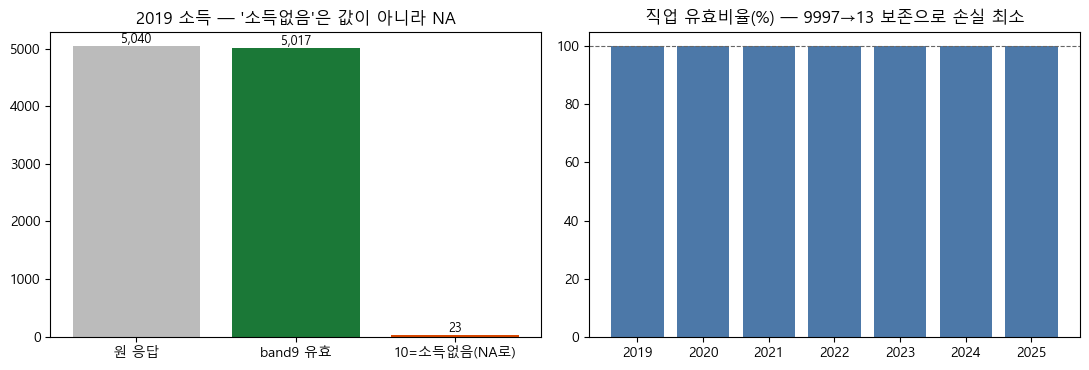

2019 소득: 원 응답 5,040 → band9 유효 5,017 (소득없음 23명을 NA로 — 평균 오염 방지)
직업 유효비율 범위: 100.0~100.0%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# (좌) 2019 소득 — 원 응답 vs band9 유효 vs '소득없음' NA
df19, _, _ = hz.read_sav_any(hz.SAV_BY_YEAR[2019])
x19 = hz._num(df19["DQ5"])
n_raw = int(x19.notna().sum())
n_ten = int((x19 == 10).sum())
n_b9 = int(panel.loc[panel["year"] == 2019, "income_band9"].notna().sum())
axes[0].bar(["원 응답", "band9 유효", "10=소득없음(NA로)"], [n_raw, n_b9, n_ten],
            color=["#bbb", "#1b7837", "#d94801"])
for i, v in enumerate([n_raw, n_b9, n_ten]):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
axes[0].set_title("2019 소득 — '소득없음'은 값이 아니라 NA")

# (우) 직업 — 연도별 유효비율(9997 보존 덕에 높음)
job_valid = panel.groupby("year")["job"].apply(lambda s: s.notna().mean() * 100)
axes[1].bar([str(y) for y in job_valid.index], job_valid.values, color="#4c78a8")
axes[1].set_ylim(0, 105); axes[1].axhline(100, ls="--", color="#666", lw=0.8)
axes[1].set_title("직업 유효비율(%) — 9997→13 보존으로 손실 최소")
fig.tight_layout(); plt.show()
print(f"2019 소득: 원 응답 {n_raw:,} → band9 유효 {n_b9:,} (소득없음 {n_ten:,}명을 NA로 — 평균 오염 방지)")
print(f"직업 유효비율 범위: {job_valid.min():.1f}~{job_valid.max():.1f}%")

## **5. [입증] 검증 셀 — 패널 값 범위 전 변수 assert**

처리 결과가 패널 전체(90,996행)에서 명세 범위를 벗어나지 않는지 일괄 판정한다 — 단위검증(§2)이 함수의 정확성을, 이 셀이 **적용 결과의 무결성**을 맡는다.

In [5]:
RANGES = {
    "sex": {1, 2}, "edu": {1, 2, 3, 4},
    "income_band9": set(range(1, 10)), "income_band7": set(range(1, 8)),
    "job": set(range(1, 14)), "region": set(range(1, 18)),
    "trust_news_overall": {1, 2, 3, 4, 5}, "trust_news_used": {1, 2, 3, 4, 5},
    "trust_society": {1, 2, 3, 4, 5},
    "cred_fair": {1, 2, 3, 4, 5}, "cred_professional": {1, 2, 3, 4, 5},
    "cred_accurate": {1, 2, 3, 4, 5}, "cred_trustworthy": {1, 2, 3, 4, 5},
    "press_free": {1, 2, 3, 4, 5}, "media_influence": {1, 2, 3, 4, 5},
}
for col, allowed in RANGES.items():
    vals = set(pd.to_numeric(panel[col], errors="coerce").dropna().unique())
    assert vals <= allowed, f"{col}: 허용 밖 값 {vals - allowed}"
print(f"(a) 범주 변수 {len(RANGES)}종 — 허용값 밖 0건 PASS")

age = pd.to_numeric(panel["age"], errors="coerce").dropna()
assert (age > 0).all() and (age < 120).all()
print(f"(b) age 범위 ({age.min():.0f}~{age.max():.0f}) PASS")

for c in hz.FIXED_POOL8:
    vals = set(pd.to_numeric(panel[c], errors="coerce").dropna().unique())
    assert vals <= {0, 1}, f"{c}: {vals}"
r8 = pd.to_numeric(panel["richness_fixed8"], errors="coerce").dropna()
assert r8.between(0, 8).all()
print(f"(c) use_* 8종 이진(0/1) + richness_fixed8 범위(0~8) PASS")

n_9997 = int((pd.to_numeric(panel["job"], errors="coerce") == 9997).sum())
assert n_9997 == 0
print(f"(d) 패널에 9997 잔존 0건(전부 13으로 재코딩) PASS")
print("\n검증 (a)~(d) 전부 PASS — 특수코드 처리 무결성 확정")

(a) 범주 변수 15종 — 허용값 밖 0건 PASS
(b) age 범위 (19~98) PASS
(c) use_* 8종 이진(0/1) + richness_fixed8 범위(0~8) PASS
(d) 패널에 9997 잔존 0건(전부 13으로 재코딩) PASS

검증 (a)~(d) 전부 PASS — 특수코드 처리 무결성 확정


## **6. 종합**

### **연구질문 답**

- **Q1** — 재코딩 함수 8종이 정상·경계·오염 입력 전수에서 명세대로 동작한다(§2, 케이스 전부 PASS). 경계 2건(소득 10→NA, 직업 9997→13)이 규칙의 요체다.
- **Q2** — 값 기반 일괄 NA였다면 2019 '소득없음' 응답자가 최고소득으로 오염되거나 직업 '기타' 응답자가 통째로 증발했다(§3~4 실측). 의미 기반 분기는 변수마다 다른 규칙을 코드북 근거로 명시한 것이다(DB①).
- **Q3** — 패널 90,996행 전 변수의 값 범위가 명세와 일치하고(§5 (a)~(c)), 특수코드 잔존은 0건(§5 (d)).

### **단계 요약**

| § | 한 일 | 판정 |
|---|------|:---:|
| 2 | 함수 8종 합성 입력 단위검증 | 전수 PASS |
| 3 | 실데이터 특수코드 빈도 실측(2019·2022) | 표 확정 |
| 4 | 처리 전/후 유효표본 변화 [시각화] | 규칙 효과 확인 |
| 5 | 패널 값 범위 일괄 assert | **PASS** |

**다음**: `15`(crosswalk 정합성 게이트)가 "어느 변수가 어느 해에 존재하는가"를, `19`(품질 게이트 종합)가 파이프라인 전체 self-validation을 닫는다. 재현: `python src/harmonize.py`.